# 02 — Mini U-Net Experiment
## Autonomous Terrain Traversability Analysis for Mars Rovers
### MSc Research Project — Model 2 of 7

**Project Title:** Autonomous Terrain Traversability Analysis for Mars Rovers Using Lightweight Semantic Segmentation  
**Dataset:** NASA AI4Mars (100 image-mask pairs)  
**Model:** Mini U-Net (Lightweight Baseline)  

---

### What this notebook does
- **Task 1:** Multi-class terrain segmentation (Soil / Bedrock / Sand / Big Rock)
- **Task 2:** Safe/Unsafe traversability mapping derived from Task 1 predictions

**Mini U-Net** is a reduced-capacity version of the classic U-Net.  
Filters are halved at every level (32→64→128→256) giving ~4× fewer parameters.  
Goal: faster inference with competitive accuracy for deployment on edge hardware.

Run this notebook **top to bottom**. It reuses the same train/val/test split as Notebook 1.

---

## Section 1 — Import Libraries

In [1]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os
import sys
import time
import random
import logging
import warnings
from pathlib import Path

# ─── Numerical / Data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Image Processing ────────────────────────────────────────────────────────
from PIL import Image
import cv2

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ─── Torchvision ─────────────────────────────────────────────────────────────
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ─── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

# ─── Excel ───────────────────────────────────────────────────────────────────
import openpyxl
from openpyxl.styles import Font, Border, Side, PatternFill, Alignment
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')
print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"Python version  : {sys.version}")

All libraries imported successfully.
PyTorch version : 2.12.0
Python version  : 3.10.16 (main, Dec 11 2024, 10:22:29) [Clang 14.0.6 ]


## Section 2 — Configuration

**Only `DATA_ROOT` needs editing** — all other paths are derived automatically.  
This notebook reuses the **same split files** created by Notebook 1 (`data/train.txt` etc.).

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROJECT CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path("/Users/rohannaidu/Desktop/Rohan/LJMU/Dataset/ai4mars-dataset-merged-0.1")
IMAGES_DIR = DATA_ROOT / "msl" / "images" / "edr"
MASKS_DIR  = DATA_ROOT / "msl" / "labels" / "train"

PROJECT_ROOT = Path("../")
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"

MODEL_NAME = "mini_unet"

SAVED_MODELS_DIR = OUTPUTS_DIR / "saved_models"          / MODEL_NAME
PRED_TASK1_DIR   = OUTPUTS_DIR / "predictions_task1"     / MODEL_NAME
TRAV_TASK2_DIR   = OUTPUTS_DIR / "traversability_task2"  / MODEL_NAME
VISUAL_DIR       = OUTPUTS_DIR / "visual_results"        / MODEL_NAME
EXCEL_DIR        = OUTPUTS_DIR / "excel_results"
LOGS_DIR         = OUTPUTS_DIR / "logs"
DATA_SPLIT_DIR   = PROJECT_ROOT / "data"   # shared with all notebooks

# ── Dataset Settings ──────────────────────────────────────────────────────────
NUM_IMAGES   = 100
TRAIN_COUNT  = 70
VAL_COUNT    = 15
TEST_COUNT   = 15
IMAGE_SIZE   = (256, 256)
RANDOM_SEED  = 42

# ── Class Labels ──────────────────────────────────────────────────────────────
NUM_CLASSES  = 4
CLASS_NAMES  = ["Soil", "Bedrock", "Sand", "Big Rock"]
IGNORE_INDEX = 255

TRAVERSABILITY_MAP = {0: 0, 1: 0, 2: 1, 3: 1}  # Safe=0, Unsafe=1
TRAV_CLASS_NAMES   = ["Safe", "Unsafe"]

# ── Training Settings ─────────────────────────────────────────────────────────
BATCH_SIZE    = 8        # larger batch — Mini U-Net is lightweight
NUM_EPOCHS    = 50
LEARNING_RATE = 0.001
NUM_WORKERS   = 0        # 0 for Mac M1 stability

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# ── Colours for visualisation ─────────────────────────────────────────────────
CLASS_COLOURS = {
    0: (180, 120,  60),
    1: (128, 128, 128),
    2: (255, 165,   0),
    3: (220,  50,  50),
}
TRAV_COLOURS = {
    0: ( 50, 205,  50),
    1: (220,  50,  50),
}

# ── Create output directories ─────────────────────────────────────────────────
for _dir in [SAVED_MODELS_DIR, PRED_TASK1_DIR, TRAV_TASK2_DIR,
             VISUAL_DIR, EXCEL_DIR, LOGS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

print(f"Device          : {DEVICE}")
print(f"Model           : {MODEL_NAME}")
print(f"Outputs dir     : {OUTPUTS_DIR.resolve()}")
print("Configuration complete.")

Device          : mps
Model           : mini_unet
Outputs dir     : /Users/rohannaidu/Desktop/Rohan/LJMU/FT/outputs
Configuration complete.


## Section 3 — Logging Setup

In [3]:
def setup_logger(log_path: Path) -> logging.Logger:
    """
    Create a logger that writes to both console and a persistent log file.

    Args:
        log_path: Full path to the .log file.

    Returns:
        Configured logging.Logger instance.
    """
    logger = logging.getLogger(MODEL_NAME)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )
    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


LOG_PATH = LOGS_DIR / f"{MODEL_NAME}.log"
logger   = setup_logger(LOG_PATH)

logger.info(f"========== {MODEL_NAME.upper()} NOTEBOOK STARTED ==========")
logger.info(f"Device   : {DEVICE}")
logger.info(f"Log file : {LOG_PATH}")

2026-05-25 09:47:47 | INFO     | ========== MINI_UNET NOTEBOOK STARTED ==========
2026-05-25 09:47:47 | INFO     | Device   : mps
2026-05-25 09:47:47 | INFO     | Log file : ../outputs/logs/mini_unet.log


## Section 4 — Load Dataset

Reuses the **same split files** from Notebook 1 (`data/train.txt`, `data/val.txt`, `data/test.txt`).  
This ensures all 7 models are evaluated on identical train/val/test sets.

In [4]:
def load_split_from_files(split_dir: Path) -> tuple:
    """
    Load pre-saved train/val/test split from .txt files.
    These files were created by Notebook 1 and are shared by all notebooks.

    Args:
        split_dir: Directory containing train.txt, val.txt, test.txt.

    Returns:
        (train_pairs, val_pairs, test_pairs) — each a list of (img_path, mask_path).
    """
    result = []
    for fname in ["train.txt", "val.txt", "test.txt"]:
        fpath = split_dir / fname
        assert fpath.exists(), (
            f"Split file not found: {fpath}\n"
            f"Run Notebook 1 first to generate the split files."
        )
        pairs = []
        with open(fpath, "r") as f:
            for line in f:
                img_p, msk_p = line.strip().split("\t")
                pairs.append((Path(img_p), Path(msk_p)))
        result.append(pairs)
        logger.info(f"Loaded {fname}: {len(pairs)} pairs")
    return tuple(result)


try:
    logger.info("Loading existing train/val/test split files...")
    train_pairs, val_pairs, test_pairs = load_split_from_files(DATA_SPLIT_DIR)
    logger.info(
        f"Split confirmed — Train: {len(train_pairs)}, "
        f"Val: {len(val_pairs)}, Test: {len(test_pairs)}"
    )
    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

except Exception as exc:
    logger.error(f"Dataset loading failed: {exc}")
    raise

2026-05-25 09:47:48 | INFO     | Loading existing train/val/test split files...
2026-05-25 09:47:48 | INFO     | Loaded train.txt: 70 pairs
2026-05-25 09:47:48 | INFO     | Loaded val.txt: 15 pairs
2026-05-25 09:47:48 | INFO     | Loaded test.txt: 15 pairs
2026-05-25 09:47:48 | INFO     | Split confirmed — Train: 70, Val: 15, Test: 15
Train: 70 | Val: 15 | Test: 15


## Section 5 — Dataset Class

**Images:** Grayscale JPG → converted to 3-channel RGB → resized to 256×256 → normalised [0,1]  
**Masks:** PNG, R-channel extracted (R=G=B in AI4Mars) → nearest-neighbour resize → NULL pixels (255) kept for `ignore_index`

In [5]:
class MarsTerrainDataset(Dataset):
    """
    PyTorch Dataset for the NASA AI4Mars terrain segmentation task.

    Each sample returns:
        image : FloatTensor [3, H, W]  — normalised to [0, 1]
        mask  : LongTensor  [H, W]     — class indices 0-3, NULL=255
    """

    def __init__(self, pairs: list, image_size: tuple = (256, 256), augment: bool = False):
        """
        Args:
            pairs      : List of (image_path, mask_path) tuples.
            image_size : Target (H, W).
            augment    : If True, apply training augmentations.
        """
        self.pairs      = pairs
        self.image_size = image_size
        self.augment    = augment

    def __len__(self) -> int:
        return len(self.pairs)

    def _load_image(self, path: Path) -> Image.Image:
        """Load Mars EDR grayscale JPG and convert to 3-channel RGB."""
        return Image.open(path).convert("RGB")

    def _load_mask(self, path: Path) -> np.ndarray:
        """
        Load AI4Mars PNG label and extract R channel.
        R=G=B: values are 0,1,2,3 (classes) or 255 (NULL).
        """
        mask_rgb = np.array(Image.open(path).convert("RGB"))
        return mask_rgb[:, :, 0].astype(np.uint8)

    def _resize_mask(self, mask: np.ndarray) -> np.ndarray:
        """Nearest-neighbour resize — preserves integer class values."""
        h, w = self.image_size
        return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    def __getitem__(self, idx: int) -> tuple:
        img_path, msk_path = self.pairs[idx]

        image = self._load_image(img_path)
        mask  = self._load_mask(msk_path)

        image = image.resize((self.image_size[1], self.image_size[0]), Image.BILINEAR)
        mask  = self._resize_mask(mask)

        if self.augment:
            image, mask = apply_augmentation(image, mask)

        image_tensor = T.ToTensor()(image)
        mask_tensor  = torch.from_numpy(mask).long()
        return image_tensor, mask_tensor

    def get_image_name(self, idx: int) -> str:
        return self.pairs[idx][0].stem


logger.info("MarsTerrainDataset class defined.")

2026-05-25 09:47:49 | INFO     | MarsTerrainDataset class defined.


## Section 6 — Data Augmentation

In [6]:
def apply_augmentation(image: Image.Image, mask: np.ndarray) -> tuple:
    """
    Apply synchronised training augmentations to an image-mask pair.

    Spatial transforms are applied identically to image and mask.
    Photometric transforms (brightness/contrast) are image-only.

    Augmentations:
        1. Random horizontal flip     (p=0.5)
        2. Small random rotation      (-10° to +10°)
        3. Random brightness jitter   (0.8–1.2)
        4. Random contrast jitter     (0.8–1.2)
        5. Random resized crop        (scale 0.8–1.0)

    Args:
        image : PIL.Image RGB.
        mask  : np.ndarray uint8 (H, W).

    Returns:
        (augmented_image, augmented_mask)
    """
    mask_pil = Image.fromarray(mask, mode="L")

    if random.random() > 0.5:
        image    = TF.hflip(image)
        mask_pil = TF.hflip(mask_pil)

    angle    = random.uniform(-10, 10)
    image    = TF.rotate(image,    angle, interpolation=T.InterpolationMode.BILINEAR, fill=0)
    mask_pil = TF.rotate(mask_pil, angle, interpolation=T.InterpolationMode.NEAREST,  fill=255)

    image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
    image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

    h, w = IMAGE_SIZE
    i, j, ch, cw = T.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(1.0, 1.0))
    image    = TF.resized_crop(image,    i, j, ch, cw, (h, w), interpolation=T.InterpolationMode.BILINEAR)
    mask_pil = TF.resized_crop(mask_pil, i, j, ch, cw, (h, w), interpolation=T.InterpolationMode.NEAREST)

    return image, np.array(mask_pil, dtype=np.uint8)


# ── Build Datasets and DataLoaders ────────────────────────────────────────────
train_dataset = MarsTerrainDataset(train_pairs, IMAGE_SIZE, augment=True)
val_dataset   = MarsTerrainDataset(val_pairs,   IMAGE_SIZE, augment=False)
test_dataset  = MarsTerrainDataset(test_pairs,  IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

logger.info(f"Train batches : {len(train_loader)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

sample_img, sample_mask = train_dataset[0]
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Image : {sample_img.shape}  range=[{sample_img.min():.2f}, {sample_img.max():.2f}]")
print(f"Mask  : {sample_mask.shape} unique={sample_mask.unique().tolist()}")

2026-05-25 09:47:50 | INFO     | Train batches : 9 | Val: 15 | Test: 15
Train: 70 | Val: 15 | Test: 15
Image : torch.Size([3, 256, 256])  range=[0.04, 0.50]
Mask  : torch.Size([256, 256]) unique=[0, 255]


## Section 7 — Model Definition: Mini U-Net

Mini U-Net reduces filter counts at every level compared to standard U-Net:

| Level     | U-Net filters | Mini U-Net filters |
|-----------|--------------|--------------------|
| Encoder 1 | 64           | 32                 |
| Encoder 2 | 128          | 64                 |
| Encoder 3 | 256          | 128                |
| Encoder 4 | 512          | 256                |
| Bottleneck| 1024         | 512                |

This reduces parameters from ~31M to ~8M while keeping the full encoder-decoder structure.

In [7]:
class DoubleConv(nn.Module):
    """
    Two consecutive Conv2d → BatchNorm → ReLU blocks.
    Shared building block for encoder and decoder.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):
    """DoubleConv → MaxPool. Returns skip connection and downsampled feature map."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> tuple:
        skip = self.conv(x)
        down = self.pool(skip)
        return skip, down


class DecoderBlock(nn.Module):
    """Bilinear upsample → concat skip → DoubleConv."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))


class MiniUNet(nn.Module):
    """
    Mini U-Net — lightweight variant with halved filter counts.

    Architecture:
        Encoder    : 4 levels  (32 → 64 → 128 → 256)
        Bottleneck :           (256 → 512)
        Decoder    : 4 levels  (512+256→256 → ... → 32)
        Head       : 1×1 Conv → num_classes

    Input  : [B, 3, 256, 256]
    Output : [B, num_classes, 256, 256]
    """

    def __init__(self, in_channels: int = 3, num_classes: int = 4):
        super().__init__()

        # Encoder — half the filters of standard U-Net
        self.enc1 = EncoderBlock(in_channels,  32)
        self.enc2 = EncoderBlock(32,           64)
        self.enc3 = EncoderBlock(64,          128)
        self.enc4 = EncoderBlock(128,         256)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.dec4 = DecoderBlock(512 + 256, 256)
        self.dec3 = DecoderBlock(256 + 128, 128)
        self.dec2 = DecoderBlock(128 +  64,  64)
        self.dec1 = DecoderBlock( 64 +  32,  32)

        # Output head
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        x = self.bottleneck(x)

        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        return self.head(x)


# ── Instantiate model ─────────────────────────────────────────────────────────
model = MiniUNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)

num_params    = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

logger.info(f"Model           : Mini U-Net")
logger.info(f"Parameters      : {num_params:,}")
logger.info(f"Model size      : {model_size_mb:.2f} MB")
logger.info(f"Device          : {DEVICE}")

print(f"Model           : Mini U-Net")
print(f"Trainable params: {num_params:,}")
print(f"Model size      : {model_size_mb:.2f} MB")
print(f"Device          : {DEVICE}")

with torch.no_grad():
    dummy = torch.zeros(1, 3, *IMAGE_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape    : {out.shape}  ✓ expected [1, 4, 256, 256]")

2026-05-25 09:47:52 | INFO     | Model           : Mini U-Net
2026-05-25 09:47:52 | INFO     | Parameters      : 7,849,700
2026-05-25 09:47:52 | INFO     | Model size      : 29.94 MB
2026-05-25 09:47:52 | INFO     | Device          : mps
Model           : Mini U-Net
Trainable params: 7,849,700
Model size      : 29.94 MB
Device          : mps
Output shape    : torch.Size([1, 4, 256, 256])  ✓ expected [1, 4, 256, 256]


## Section 8 — Loss Functions

**Weighted CrossEntropyLoss + Dice Loss**  
Class weights are computed from the training masks (inverse frequency).  
This prevents the model collapsing to predicting only the dominant class (Soil).

In [8]:
def compute_class_weights(
    pairs: list,
    num_classes: int = 4,
    ignore_index: int = 255
) -> torch.Tensor:
    """
    Compute inverse-frequency class weights from training masks.
    Rare classes (sand, big rock) receive higher weights so the model
    cannot collapse to predicting only the dominant class.

    Args:
        pairs        : Train split (image_path, mask_path) list.
        num_classes  : Number of terrain classes.
        ignore_index : NULL pixel value to exclude.

    Returns:
        FloatTensor [num_classes] on DEVICE.
    """
    logger.info("Computing class weights from training masks...")
    counts = np.zeros(num_classes, dtype=np.float64)

    for _, mask_path in pairs:
        mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
        mask     = mask_rgb[:, :, 0].astype(np.uint8)
        for cls in range(num_classes):
            counts[cls] += np.sum(mask == cls)

    total   = counts.sum()
    counts  = np.where(counts == 0, 1, counts)   # avoid division by zero
    weights = total / (num_classes * counts)
    weights = weights / weights.sum() * num_classes   # normalise

    logger.info(f"Class pixel counts : {counts.astype(int)}")
    logger.info(f"Class weights      : {np.round(weights, 4)}")

    print("Class weights computed:")
    for i, (cls, w) in enumerate(zip(CLASS_NAMES, weights)):
        print(f"  {cls:<12}: count={int(counts[i]):>10,}  weight={w:.4f}")

    return torch.FloatTensor(weights).to(DEVICE)


class DiceLoss(nn.Module):
    """
    Multi-class Dice Loss (manual PyTorch implementation).
    Excludes ignore_index pixels from computation.
    Dice = 2|X∩Y| / (|X|+|Y|)  →  Loss = 1 - Dice
    """

    def __init__(self, num_classes: int = 4, ignore_index: int = 255, smooth: float = 1e-6):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs  = F.softmax(logits, dim=1)
        valid  = (targets != self.ignore_index)

        targets_clean = targets.clone()
        targets_clean[~valid] = 0

        one_hot  = F.one_hot(targets_clean, self.num_classes).permute(0, 3, 1, 2).float()
        valid_4d = valid.unsqueeze(1).expand_as(one_hot)
        one_hot  = one_hot * valid_4d
        probs    = probs   * valid_4d

        dims         = (0, 2, 3)
        intersection = (probs * one_hot).sum(dim=dims)
        cardinality  = (probs + one_hot).sum(dim=dims)
        dice         = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    Total Loss = Weighted CrossEntropyLoss + DiceLoss.
    Both components use ignore_index=255 for NULL pixels.
    """

    def __init__(self, class_weights: torch.Tensor, num_classes: int = 4, ignore_index: int = 255):
        super().__init__()
        self.ce_loss   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice_loss = DiceLoss(num_classes=num_classes, ignore_index=ignore_index)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return self.ce_loss(logits, targets) + self.dice_loss(logits, targets)


# ── Compute weights and build loss ────────────────────────────────────────────
class_weights = compute_class_weights(train_pairs, NUM_CLASSES, IGNORE_INDEX)
criterion     = CombinedLoss(class_weights=class_weights, num_classes=NUM_CLASSES,
                              ignore_index=IGNORE_INDEX)

logger.info("Loss: Weighted CrossEntropyLoss + DiceLoss (ignore_index=255)")
print("\nLoss function ready.")

2026-05-25 09:47:54 | INFO     | Computing class weights from training masks...
2026-05-25 09:47:54 | INFO     | Class pixel counts : [18107523  7550767 10222175   205063]
2026-05-25 09:47:54 | INFO     | Class weights      : [0.0428 0.1026 0.0758 3.7788]
Class weights computed:
  Soil        : count=18,107,523  weight=0.0428
  Bedrock     : count= 7,550,767  weight=0.1026
  Sand        : count=10,222,175  weight=0.0758
  Big Rock    : count=   205,063  weight=3.7788
2026-05-25 09:47:54 | INFO     | Loss: Weighted CrossEntropyLoss + DiceLoss (ignore_index=255)

Loss function ready.


## Section 9 — Task 1 Metrics

In [9]:
def compute_task1_metrics(
    pred_mask: np.ndarray,
    gt_mask: np.ndarray,
    num_classes: int = 4,
    ignore_index: int = 255
) -> dict:
    """
    Compute Task 1 segmentation metrics for one image.

    Args:
        pred_mask    : Predicted class mask (H, W) np.uint8.
        gt_mask      : Ground truth mask    (H, W) np.uint8.
        num_classes  : Number of terrain classes.
        ignore_index : NULL pixel value excluded from metrics.

    Returns:
        dict: pixel_accuracy, mean_iou, dice_score, f1_score,
              soil_recall, bedrock_recall, sand_recall, big_rock_recall
    """
    valid   = gt_mask != ignore_index
    gt_flat = gt_mask[valid].astype(np.int32)
    pr_flat = pred_mask[valid].astype(np.int32)

    if len(gt_flat) == 0:
        return {k: 0.0 for k in [
            "pixel_accuracy", "mean_iou", "dice_score", "f1_score",
            "soil_recall", "bedrock_recall", "sand_recall", "big_rock_recall"
        ]}

    pixel_acc   = float(np.mean(gt_flat == pr_flat))
    iou_list    = []
    dice_list   = []
    recall_list = []

    for cls in range(num_classes):
        tp    = int(np.sum((gt_flat == cls) & (pr_flat == cls)))
        fp    = int(np.sum((gt_flat != cls) & (pr_flat == cls)))
        fn    = int(np.sum((gt_flat == cls) & (pr_flat != cls)))

        iou   = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        dice  = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        iou_list.append(iou)
        dice_list.append(dice)
        recall_list.append(rec)

    return {
        "pixel_accuracy" : round(pixel_acc,       4),
        "mean_iou"       : round(np.mean(iou_list), 4),
        "dice_score"     : round(np.mean(dice_list), 4),
        "f1_score"       : round(np.mean(dice_list), 4),
        "soil_recall"    : round(recall_list[0],  4),
        "bedrock_recall" : round(recall_list[1],  4),
        "sand_recall"    : round(recall_list[2],  4),
        "big_rock_recall": round(recall_list[3],  4),
    }


logger.info("Task 1 metrics function defined.")
print("Task 1 metrics ready.")

2026-05-25 09:47:55 | INFO     | Task 1 metrics function defined.
Task 1 metrics ready.


## Section 10 — Task 2 Metrics

In [10]:
def convert_to_traversability(
    class_mask: np.ndarray,
    trav_map: dict = TRAVERSABILITY_MAP,
    ignore_index: int = 255
) -> np.ndarray:
    """
    Convert 4-class terrain mask → binary safe/unsafe mask.
    Soil(0), Bedrock(1) → Safe(0) | Sand(2), Big Rock(3) → Unsafe(1)
    NULL(255) → kept as 255.
    """
    trav_mask = np.full_like(class_mask, ignore_index, dtype=np.uint8)
    for terrain_cls, trav_cls in trav_map.items():
        trav_mask[class_mask == terrain_cls] = trav_cls
    return trav_mask


def compute_task2_metrics(
    pred_trav: np.ndarray,
    gt_trav: np.ndarray,
    ignore_index: int = 255
) -> dict:
    """
    Compute Task 2 safe/unsafe metrics for one image.
    Positive class = Unsafe (1).

    Args:
        pred_trav    : Predicted traversability (H, W) {0,1,255}.
        gt_trav      : Ground truth traversability (H, W) {0,1,255}.
        ignore_index : Pixels to exclude.

    Returns:
        dict: safe_unsafe_accuracy, safe/unsafe precision & recall,
              hazard_fnr, safe_unsafe_f1, tp, tn, fp, fn
    """
    valid   = gt_trav != ignore_index
    gt_flat = gt_trav[valid].astype(np.int32)
    pr_flat = pred_trav[valid].astype(np.int32)

    if len(gt_flat) == 0:
        return {k: 0 for k in [
            "safe_unsafe_accuracy", "safe_precision", "unsafe_precision",
            "safe_recall", "unsafe_recall", "hazard_fnr",
            "safe_unsafe_f1", "tp", "tn", "fp", "fn"
        ]}

    tp = int(np.sum((gt_flat == 1) & (pr_flat == 1)))
    tn = int(np.sum((gt_flat == 0) & (pr_flat == 0)))
    fp = int(np.sum((gt_flat == 0) & (pr_flat == 1)))
    fn = int(np.sum((gt_flat == 1) & (pr_flat == 0)))

    total        = tp + tn + fp + fn
    accuracy     = (tp + tn) / total if total > 0 else 0.0
    safe_prec    = tn / (tn + fn)   if (tn + fn) > 0   else 0.0
    unsafe_prec  = tp / (tp + fp)   if (tp + fp) > 0   else 0.0
    safe_recall  = tn / (tn + fp)   if (tn + fp) > 0   else 0.0
    unsafe_recall= tp / (tp + fn)   if (tp + fn) > 0   else 0.0
    hazard_fnr   = fn / (fn + tp)   if (fn + tp) > 0   else 0.0

    f1_safe   = (2*safe_prec*safe_recall)    / (safe_prec+safe_recall)    if (safe_prec+safe_recall)    > 0 else 0.0
    f1_unsafe = (2*unsafe_prec*unsafe_recall)/ (unsafe_prec+unsafe_recall)if (unsafe_prec+unsafe_recall)> 0 else 0.0

    return {
        "safe_unsafe_accuracy" : round(accuracy,       4),
        "safe_precision"       : round(safe_prec,      4),
        "unsafe_precision"     : round(unsafe_prec,    4),
        "safe_recall"          : round(safe_recall,    4),
        "unsafe_recall"        : round(unsafe_recall,  4),
        "hazard_fnr"           : round(hazard_fnr,     4),
        "safe_unsafe_f1"       : round((f1_safe+f1_unsafe)/2, 4),
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }


logger.info("Task 2 metrics function defined.")
print("Task 2 metrics ready.")

2026-05-25 09:47:56 | INFO     | Task 2 metrics function defined.
Task 2 metrics ready.


## Section 11 — Training Functions

In [11]:
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> tuple:
    """
    Run one validation pass and return (avg_loss, avg_miou, avg_dice).
    """
    model.eval()
    total_loss = 0.0
    all_miou, all_dice = [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device)
            logits = model(images)
            loss   = criterion(logits, masks)
            total_loss += loss.item()

            preds = logits.argmax(dim=1).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)

            for pred, gt in zip(preds, gts):
                m = compute_task1_metrics(pred, gt, NUM_CLASSES, IGNORE_INDEX)
                all_miou.append(m["mean_iou"])
                all_dice.append(m["dice_score"])

    return (total_loss / len(loader),
            float(np.mean(all_miou)),
            float(np.mean(all_dice)))


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    num_epochs: int,
    learning_rate: float,
    device: torch.device,
    save_path: Path
) -> dict:
    """
    Full training loop with validation and best-model checkpoint.
    Best model is saved by highest validation Mean IoU.
    ReduceLROnPlateau halves LR after 5 epochs with no improvement.

    Returns:
        history dict: train_loss, val_loss, val_miou, val_dice, best_epoch, best_miou
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # Note: verbose removed — not supported in PyTorch 2.x
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=5, factor=0.5
    )

    history   = {"train_loss": [], "val_loss": [], "val_miou": [], "val_dice": []}
    best_miou = -1.0
    best_epoch = 0

    logger.info(f"Training started — {num_epochs} epochs, lr={learning_rate}, "
                f"batch={BATCH_SIZE}")

    for epoch in range(1, num_epochs + 1):
        # Training
        model.train()
        epoch_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks  = masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)

        # Validation
        avg_val_loss, avg_val_miou, avg_val_dice = validate_one_epoch(
            model, val_loader, criterion, device
        )
        scheduler.step(avg_val_miou)

        history["train_loss"].append(round(avg_train,    4))
        history["val_loss"].append(round(avg_val_loss,   4))
        history["val_miou"].append(round(avg_val_miou,   4))
        history["val_dice"].append(round(avg_val_dice,   4))

        logger.info(f"Epoch {epoch:03d}/{num_epochs} | "
                    f"Train: {avg_train:.4f} | Val: {avg_val_loss:.4f} | "
                    f"mIoU: {avg_val_miou:.4f}")
        print(f"Epoch {epoch:03d}/{num_epochs} | "
              f"Train: {avg_train:.4f} | Val: {avg_val_loss:.4f} | "
              f"mIoU: {avg_val_miou:.4f}", flush=True)

        if avg_val_miou > best_miou:
            best_miou  = avg_val_miou
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            logger.info(f"  ✓ Best model saved (mIoU={best_miou:.4f})")

    history["best_epoch"] = best_epoch
    history["best_miou"]  = best_miou
    logger.info(f"Training done. Best epoch: {best_epoch}, Best mIoU: {best_miou:.4f}")
    return history


print("Training functions defined. Ready to train.")

Training functions defined. Ready to train.


## Section 12 — Train and Save Best Model

2026-05-25 09:47:58 | INFO     | Training started — 50 epochs, lr=0.001, batch=8
2026-05-25 09:48:12 | INFO     | Epoch 001/50 | Train: 2.2349 | Val: 2.1392 | mIoU: 0.0986
Epoch 001/50 | Train: 2.2349 | Val: 2.1392 | mIoU: 0.0986
2026-05-25 09:48:13 | INFO     |   ✓ Best model saved (mIoU=0.0986)
2026-05-25 09:48:17 | INFO     | Epoch 002/50 | Train: 2.1075 | Val: 2.4742 | mIoU: 0.1178
Epoch 002/50 | Train: 2.1075 | Val: 2.4742 | mIoU: 0.1178
2026-05-25 09:48:17 | INFO     |   ✓ Best model saved (mIoU=0.1178)
2026-05-25 09:48:22 | INFO     | Epoch 003/50 | Train: 2.0343 | Val: 4.3373 | mIoU: 0.0986
Epoch 003/50 | Train: 2.0343 | Val: 4.3373 | mIoU: 0.0986
2026-05-25 09:48:27 | INFO     | Epoch 004/50 | Train: 1.9698 | Val: 3.6257 | mIoU: 0.0986
Epoch 004/50 | Train: 1.9698 | Val: 3.6257 | mIoU: 0.0986
2026-05-25 09:48:31 | INFO     | Epoch 005/50 | Train: 1.9576 | Val: 2.5295 | mIoU: 0.0986
Epoch 005/50 | Train: 1.9576 | Val: 2.5295 | mIoU: 0.0986
2026-05-25 09:48:36 | INFO     | Epoch

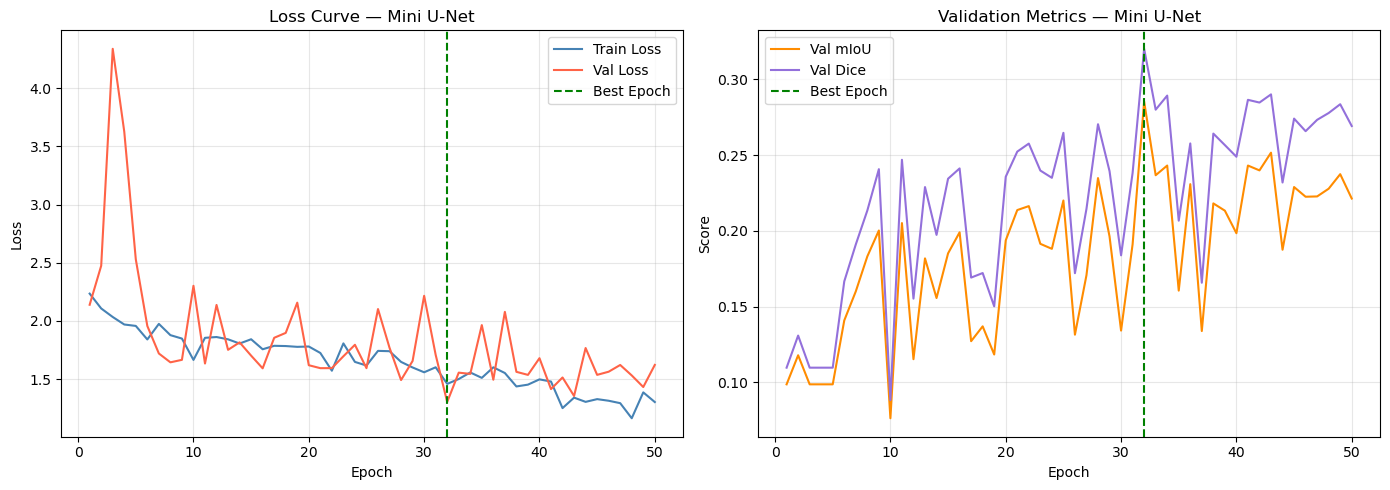

Curves saved: ../outputs/visual_results/mini_unet/training_curves.png


In [12]:
BEST_MODEL_PATH = SAVED_MODELS_DIR / f"best_{MODEL_NAME}.pth"

try:
    training_history = train_model(
        model         = model,
        train_loader  = train_loader,
        val_loader    = val_loader,
        criterion     = criterion,
        num_epochs    = NUM_EPOCHS,
        learning_rate = LEARNING_RATE,
        device        = DEVICE,
        save_path     = BEST_MODEL_PATH
    )
    print(f"\nBest model saved : {BEST_MODEL_PATH}")
    print(f"Best epoch       : {training_history['best_epoch']}")
    print(f"Best val mIoU    : {training_history['best_miou']:.4f}")

except Exception as exc:
    logger.error(f"Training failed: {exc}")
    raise

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, training_history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, training_history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best Epoch")
axes[0].set_title("Loss Curve — Mini U-Net")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, training_history["val_miou"], label="Val mIoU", color="darkorange")
axes[1].plot(epochs, training_history["val_dice"], label="Val Dice", color="mediumpurple")
axes[1].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best Epoch")
axes[1].set_title("Validation Metrics — Mini U-Net")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

curve_path = VISUAL_DIR / "training_curves.png"
plt.tight_layout()
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Curves saved: {curve_path}")

## Section 13 — Evaluate Task 1 on Test Set

In [14]:
logger.info("Loading best model weights for evaluation...")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

task1_results    = []
pred_masks_list  = []
gt_masks_list    = []
image_names      = []

logger.info("Task 1 evaluation started...")

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        img_name = test_dataset.get_image_name(idx)
        image_names.append(img_name)

        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        start = time.perf_counter()
        logits = model(images)
        if DEVICE.type == "mps":
            torch.mps.synchronize()
        elif DEVICE.type == "cuda":
            torch.cuda.synchronize()
        inf_ms = (time.perf_counter() - start) * 1000.0

        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        gt_mask   = masks.squeeze(0).cpu().numpy().astype(np.uint8)

        pred_masks_list.append(pred_mask)
        gt_masks_list.append(gt_mask)

        m = compute_task1_metrics(pred_mask, gt_mask, NUM_CLASSES, IGNORE_INDEX)
        m["image_name"]   = img_name
        m["model_name"]   = MODEL_NAME
        m["inference_ms"] = round(inf_ms, 2)
        m["fps"]          = round(1000.0 / inf_ms if inf_ms > 0 else 0, 2)
        task1_results.append(m)

        logger.info(f"[Task1] {img_name} | mIoU={m['mean_iou']:.4f} | "
                    f"Dice={m['dice_score']:.4f} | {inf_ms:.1f}ms")

logger.info(f"Task 1 evaluation done — {len(task1_results)} images.")

print(f"\nTask 1 Results — Mini U-Net")
print(f"  Avg Pixel Accuracy : {np.mean([r['pixel_accuracy'] for r in task1_results]):.4f}")
print(f"  Avg Mean IoU       : {np.mean([r['mean_iou']       for r in task1_results]):.4f}")
print(f"  Avg Dice Score     : {np.mean([r['dice_score']     for r in task1_results]):.4f}")
print(f"  Avg Inference      : {np.mean([r['inference_ms']   for r in task1_results]):.2f} ms")

2026-05-25 09:52:09 | INFO     | Loading best model weights for evaluation...
2026-05-25 09:52:09 | INFO     | Task 1 evaluation started...
2026-05-25 09:52:09 | INFO     | [Task1] NLA_398561822EDR_F0030004NCAM00400M1 | mIoU=0.2047 | Dice=0.2251 | 40.0ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_407975674EDR_F0050432NCAM07814M1 | mIoU=0.0000 | Dice=0.0000 | 21.8ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_402117478EDR_F0043200NCAM00439M1 | mIoU=0.2352 | Dice=0.3188 | 20.8ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_398920052EDR_F0030078NCAM00303M1 | mIoU=0.1366 | Dice=0.1767 | 20.1ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_408145785EDR_F0050624NCAM00454M1 | mIoU=0.1815 | Dice=0.2662 | 19.5ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_408145730EDR_F0050624NCAM00454M1 | mIoU=0.2647 | Dice=0.3411 | 19.8ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_398920451EDR_F0030078NCAM00304M1 | mIoU=0.2020 | Dice=0.2234 | 17.5ms
2026-05-25 09:52:09 | INFO     | [Task1] NLA_403977615E

## Section 14 — Save Predicted Segmentation Masks

In [15]:
for idx, (pred_mask, img_name) in enumerate(zip(pred_masks_list, image_names)):
    pred_path = PRED_TASK1_DIR / f"{img_name}_pred_task1.png"
    Image.fromarray(pred_mask, mode="L").save(pred_path)
    task1_results[idx]["pred_mask_path"] = str(pred_path)

logger.info(f"Task 1 masks saved: {PRED_TASK1_DIR}")
print(f"Predicted masks saved: {PRED_TASK1_DIR}")

2026-05-25 09:52:11 | INFO     | Task 1 masks saved: ../outputs/predictions_task1/mini_unet
Predicted masks saved: ../outputs/predictions_task1/mini_unet


## Section 15 — Evaluate Task 2

In [16]:
task2_results  = []
pred_trav_list = []
gt_trav_list   = []

for idx, (pred_mask, gt_mask, img_name) in enumerate(
    zip(pred_masks_list, gt_masks_list, image_names)
):
    pred_trav = convert_to_traversability(pred_mask, TRAVERSABILITY_MAP, IGNORE_INDEX)
    gt_trav   = convert_to_traversability(gt_mask,   TRAVERSABILITY_MAP, IGNORE_INDEX)

    pred_trav_list.append(pred_trav)
    gt_trav_list.append(gt_trav)

    t2 = compute_task2_metrics(pred_trav, gt_trav, IGNORE_INDEX)
    t2["image_name"] = img_name
    t2["model_name"] = MODEL_NAME
    task2_results.append(t2)

    logger.info(f"[Task2] {img_name} | Unsafe Recall={t2['unsafe_recall']:.4f} | "
                f"Hazard FNR={t2['hazard_fnr']:.4f}")

print(f"\nTask 2 Results — Mini U-Net")
print(f"  Safe/Unsafe Accuracy : {np.mean([r['safe_unsafe_accuracy'] for r in task2_results]):.4f}")
print(f"  Unsafe Recall ★      : {np.mean([r['unsafe_recall']        for r in task2_results]):.4f}")
print(f"  Hazard FNR ★         : {np.mean([r['hazard_fnr']           for r in task2_results]):.4f}")
print(f"  Safe/Unsafe F1       : {np.mean([r['safe_unsafe_f1']       for r in task2_results]):.4f}")

2026-05-25 09:52:13 | INFO     | [Task2] NLA_398561822EDR_F0030004NCAM00400M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_407975674EDR_F0050432NCAM07814M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_402117478EDR_F0043200NCAM00439M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_398920052EDR_F0030078NCAM00303M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_408145785EDR_F0050624NCAM00454M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_408145730EDR_F0050624NCAM00454M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_398920451EDR_F0030078NCAM00304M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-25 09:52:13 | INFO     | [Task2] NLA_403977615EDR_F0050104NCAM00107M1 | Unsafe Recall=0.7991 | Hazard FNR=0.2009
2026-05-25 09:52:13 | INFO     |

## Section 16 — Save Traversability Maps

In [17]:
for idx, (pred_trav, img_name) in enumerate(zip(pred_trav_list, image_names)):
    trav_path = TRAV_TASK2_DIR / f"{img_name}_trav_task2.png"
    Image.fromarray(pred_trav, mode="L").save(trav_path)
    task2_results[idx]["trav_map_path"] = str(trav_path)

logger.info(f"Task 2 traversability maps saved: {TRAV_TASK2_DIR}")
print(f"Traversability maps saved: {TRAV_TASK2_DIR}")

2026-05-25 09:52:15 | INFO     | Task 2 traversability maps saved: ../outputs/traversability_task2/mini_unet
Traversability maps saved: ../outputs/traversability_task2/mini_unet


## Section 17 — Merge Image-wise Results

In [18]:
combined_results = []

for t1, t2 in zip(task1_results, task2_results):
    combined_results.append({
        "image_name"           : t1["image_name"],
        "model_name"           : MODEL_NAME,
        "pixel_accuracy"       : t1["pixel_accuracy"],
        "mean_iou"             : t1["mean_iou"],
        "dice_score"           : t1["dice_score"],
        "f1_score"             : t1["f1_score"],
        "soil_recall"          : t1["soil_recall"],
        "bedrock_recall"       : t1["bedrock_recall"],
        "sand_recall"          : t1["sand_recall"],
        "big_rock_recall"      : t1["big_rock_recall"],
        "inference_ms"         : t1["inference_ms"],
        "fps"                  : t1["fps"],
        "pred_mask_path"       : t1.get("pred_mask_path", ""),
        "safe_unsafe_accuracy" : t2["safe_unsafe_accuracy"],
        "safe_precision"       : t2["safe_precision"],
        "unsafe_precision"     : t2["unsafe_precision"],
        "safe_recall"          : t2["safe_recall"],
        "unsafe_recall"        : t2["unsafe_recall"],
        "hazard_fnr"           : t2["hazard_fnr"],
        "safe_unsafe_f1"       : t2["safe_unsafe_f1"],
        "tp"                   : t2["tp"],
        "tn"                   : t2["tn"],
        "fp"                   : t2["fp"],
        "fn"                   : t2["fn"],
        "trav_map_path"        : t2.get("trav_map_path", ""),
    })

print(f"Combined result records: {len(combined_results)}")

Combined result records: 15


## Section 18 — Save Excel Report (6 Sheets)

In [19]:
def style_header_row(ws, row_num: int, fill_colour: str = "4472C4"):
    """Bold white text on coloured background for header rows."""
    fill = PatternFill("solid", fgColor=fill_colour)
    font = Font(bold=True, color="FFFFFF")
    for cell in ws[row_num]:
        if cell.value is not None:
            cell.font      = font
            cell.fill      = fill
            cell.alignment = Alignment(horizontal="center", wrap_text=True)


def apply_borders(ws, min_row, max_row, min_col, max_col):
    """Thin border on all cells in range."""
    thin   = Side(style="thin")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    for row in ws.iter_rows(min_row=min_row, max_row=max_row,
                             min_col=min_col, max_col=max_col):
        for cell in row:
            cell.border = border


def auto_fit_columns(ws, padding: int = 4):
    """Set column width to fit longest cell value."""
    for col in ws.columns:
        max_len = max((len(str(cell.value or "")) for cell in col), default=0)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + padding, 50)


def build_excel_report(save_path, training_history, combined_results,
                        model_name, num_params, model_size_mb):
    """
    Build 6-sheet Excel report:
        1. Training_History
        2. Task1_Image_Wise_Results
        3. Task2_Image_Wise_Results
        4. Task1_Overall_Summary
        5. Task2_Overall_Summary
        6. Final_Model_Conclusion
    """
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    def _avg(key):
        return round(float(np.mean([r[key] for r in combined_results])), 4)

    # ── Sheet 1: Training History ─────────────────────────────────────────────
    ws1 = wb.create_sheet("Training_History")
    ws1.append(["Epoch", "Training Loss", "Validation Loss",
                "Validation Mean IoU", "Validation Dice Score"])
    style_header_row(ws1, 1)
    for ep in range(len(training_history["train_loss"])):
        ws1.append([ep + 1,
                    training_history["train_loss"][ep],
                    training_history["val_loss"][ep],
                    training_history["val_miou"][ep],
                    training_history["val_dice"][ep]])
    apply_borders(ws1, 1, ws1.max_row, 1, ws1.max_column)
    auto_fit_columns(ws1)
    ws1.freeze_panes = "A2"

    # ── Sheet 2: Task1 Image-Wise ─────────────────────────────────────────────
    ws2 = wb.create_sheet("Task1_Image_Wise_Results")
    ws2.append(["Image Name", "Model Name", "Pixel Accuracy", "Mean IoU",
                "Dice Score", "F1-Score", "Soil Recall", "Bedrock Recall",
                "Sand Recall", "Big Rock Recall", "Inference Time ms", "FPS",
                "Prediction Mask Path"])
    style_header_row(ws2, 1)
    for r in combined_results:
        ws2.append([r["image_name"], r["model_name"], r["pixel_accuracy"],
                    r["mean_iou"], r["dice_score"], r["f1_score"],
                    r["soil_recall"], r["bedrock_recall"], r["sand_recall"],
                    r["big_rock_recall"], r["inference_ms"], r["fps"],
                    r["pred_mask_path"]])
    apply_borders(ws2, 1, ws2.max_row, 1, ws2.max_column)
    auto_fit_columns(ws2)
    ws2.freeze_panes = "A2"

    # ── Sheet 3: Task2 Image-Wise ─────────────────────────────────────────────
    ws3 = wb.create_sheet("Task2_Image_Wise_Results")
    ws3.append(["Image Name", "Model Name", "Safe/Unsafe Accuracy",
                "Safe Precision", "Unsafe Precision", "Safe Recall",
                "Unsafe Recall", "Hazard FNR", "Safe/Unsafe F1-Score",
                "TP", "TN", "FP", "FN", "Safe/Unsafe Map Path", "Visual Output Path"])
    style_header_row(ws3, 1)
    for r in combined_results:
        ws3.append([r["image_name"], r["model_name"], r["safe_unsafe_accuracy"],
                    r["safe_precision"], r["unsafe_precision"], r["safe_recall"],
                    r["unsafe_recall"], r["hazard_fnr"], r["safe_unsafe_f1"],
                    r["tp"], r["tn"], r["fp"], r["fn"],
                    r.get("trav_map_path", ""), r.get("visual_path", "")])
    apply_borders(ws3, 1, ws3.max_row, 1, ws3.max_column)
    auto_fit_columns(ws3)
    ws3.freeze_panes = "A2"

    # ── Sheet 4: Task1 Summary ────────────────────────────────────────────────
    ws4 = wb.create_sheet("Task1_Overall_Summary")
    ws4.append(["Model Name", "Average Pixel Accuracy", "Average Mean IoU",
                "Average Dice Score", "Average F1-Score",
                "Average Soil Recall", "Average Bedrock Recall",
                "Average Sand Recall", "Average Big Rock Recall",
                "Model Size MB", "Number of Parameters",
                "Average Inference Time ms", "Average FPS", "Remarks"])
    style_header_row(ws4, 1)
    avg_fps = round(1000 / _avg("inference_ms"), 2) if _avg("inference_ms") > 0 else 0
    ws4.append([model_name.upper(),
                _avg("pixel_accuracy"), _avg("mean_iou"), _avg("dice_score"),
                _avg("f1_score"), _avg("soil_recall"), _avg("bedrock_recall"),
                _avg("sand_recall"), _avg("big_rock_recall"),
                round(model_size_mb, 2), num_params,
                _avg("inference_ms"), avg_fps,
                "Lightweight Mini U-Net — halved filters vs standard U-Net"])
    apply_borders(ws4, 1, ws4.max_row, 1, ws4.max_column)
    auto_fit_columns(ws4)

    # ── Sheet 5: Task2 Summary ────────────────────────────────────────────────
    ws5 = wb.create_sheet("Task2_Overall_Summary")
    ws5.append(["Model Name", "Average Safe/Unsafe Accuracy",
                "Average Safe Precision", "Average Unsafe Precision",
                "Average Safe Recall", "Average Unsafe Recall",
                "Average Hazard FNR", "Average Safe/Unsafe F1-Score",
                "Total TP", "Total TN", "Total FP", "Total FN", "Remarks"])
    style_header_row(ws5, 1)
    ws5.append([model_name.upper(),
                _avg("safe_unsafe_accuracy"), _avg("safe_precision"),
                _avg("unsafe_precision"), _avg("safe_recall"), _avg("unsafe_recall"),
                _avg("hazard_fnr"), _avg("safe_unsafe_f1"),
                sum(r["tp"] for r in combined_results),
                sum(r["tn"] for r in combined_results),
                sum(r["fp"] for r in combined_results),
                sum(r["fn"] for r in combined_results),
                "Mini U-Net traversability safety performance"])
    apply_borders(ws5, 1, ws5.max_row, 1, ws5.max_column)
    auto_fit_columns(ws5)

    # ── Sheet 6: Conclusion ───────────────────────────────────────────────────
    ws6 = wb.create_sheet("Final_Model_Conclusion")
    ws6.append(["Model Name", "Best Strength", "Weakness",
                "Task 1 Summary", "Task 2 Summary", "Final Comment"])
    style_header_row(ws6, 1)
    ws6.append(["Mini U-Net",
                "Lightweight — ~4x fewer params than U-Net, faster inference",
                "Reduced capacity may miss fine-grained class boundaries",
                f"Avg mIoU={_avg('mean_iou'):.4f}, Dice={_avg('dice_score'):.4f}",
                f"Unsafe Recall={_avg('unsafe_recall'):.4f}, Hazard FNR={_avg('hazard_fnr'):.4f}",
                "Efficient model suitable for edge deployment on Mars rovers"])
    apply_borders(ws6, 1, ws6.max_row, 1, ws6.max_column)
    auto_fit_columns(ws6)

    wb.save(save_path)
    print(f"Excel saved: {save_path}")


EXCEL_SAVE_PATH = EXCEL_DIR / f"{MODEL_NAME}_results.xlsx"

try:
    build_excel_report(
        save_path        = EXCEL_SAVE_PATH,
        training_history = training_history,
        combined_results = combined_results,
        model_name       = MODEL_NAME,
        num_params       = num_params,
        model_size_mb    = model_size_mb
    )
    logger.info(f"Excel saved: {EXCEL_SAVE_PATH}")
except Exception as exc:
    logger.error(f"Excel save failed: {exc}")
    raise

Excel saved: ../outputs/excel_results/mini_unet_results.xlsx
2026-05-25 09:52:18 | INFO     | Excel saved: ../outputs/excel_results/mini_unet_results.xlsx


## Section 19 — Save Visual Outputs

5-panel comparison for every test image:  
Original · GT Terrain · Predicted Terrain · GT Traversability · Predicted Traversability

In [20]:
def mask_to_colour_image(mask, colour_map, ignore_index=255):
    """Convert integer class mask to RGB colour image."""
    h, w   = mask.shape
    colour = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, rgb in colour_map.items():
        colour[mask == cls_id] = rgb
    return colour


def save_visual_comparison(orig_tensor, gt_mask, pred_mask,
                            gt_trav, pred_trav, save_path, img_name):
    """
    Save 5-panel comparison figure for one test image.
    Panels: Original | GT Terrain | Pred Terrain | GT Safe/Unsafe | Pred Safe/Unsafe
    """
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Mini U-Net | {img_name}", fontsize=11, fontweight="bold")

    img_np = np.clip(orig_tensor.permute(1, 2, 0).numpy(), 0, 1)
    axes[0].imshow(img_np, cmap="gray");          axes[0].set_title("Original");         axes[0].axis("off")
    axes[1].imshow(mask_to_colour_image(gt_mask,   CLASS_COLOURS)); axes[1].set_title("GT Terrain");    axes[1].axis("off")
    axes[2].imshow(mask_to_colour_image(pred_mask, CLASS_COLOURS)); axes[2].set_title("Pred Terrain");  axes[2].axis("off")
    axes[3].imshow(mask_to_colour_image(gt_trav,   TRAV_COLOURS));  axes[3].set_title("GT Safe/Unsafe");axes[3].axis("off")
    axes[4].imshow(mask_to_colour_image(pred_trav, TRAV_COLOURS));  axes[4].set_title("Pred Safe/Unsafe"); axes[4].axis("off")

    patches = [mpatches.Patch(color=np.array(c)/255, label=n)
               for n, c in zip(CLASS_NAMES, CLASS_COLOURS.values())]
    fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


logger.info("Saving visual comparison images...")

for idx in range(len(test_dataset)):
    img_name = image_names[idx]
    vis_path = VISUAL_DIR / f"{img_name}_visual.png"
    orig_tensor, _ = test_dataset[idx]

    save_visual_comparison(
        orig_tensor  = orig_tensor,
        gt_mask      = gt_masks_list[idx],
        pred_mask    = pred_masks_list[idx],
        gt_trav      = gt_trav_list[idx],
        pred_trav    = pred_trav_list[idx],
        save_path    = vis_path,
        img_name     = img_name
    )
    combined_results[idx]["visual_path"] = str(vis_path)

logger.info(f"Visuals saved: {VISUAL_DIR}")
print(f"Visual outputs saved: {VISUAL_DIR}  ({len(test_dataset)} images)")

2026-05-25 09:52:19 | INFO     | Saving visual comparison images...
2026-05-25 09:52:24 | INFO     | Visuals saved: ../outputs/visual_results/mini_unet
Visual outputs saved: ../outputs/visual_results/mini_unet  (15 images)


## Section 20 — Final Summary

In [21]:
def _avg(key):
    return round(float(np.mean([r[key] for r in combined_results])), 4)

print("\n" + "="*65)
print(f"  FINAL SUMMARY — Mini U-Net (EXP-02)")
print("="*65)

print(f"\n  MODEL INFO")
print(f"    Model Name        : Mini U-Net")
print(f"    Parameters        : {num_params:,}")
print(f"    Model Size        : {model_size_mb:.2f} MB")
print(f"    Best Epoch        : {training_history['best_epoch']}")
print(f"    Best Val mIoU     : {training_history['best_miou']:.4f}")

print(f"\n  TASK 1 — TERRAIN SEGMENTATION (Test Set, 15 images)")
print(f"    Pixel Accuracy    : {_avg('pixel_accuracy'):.4f}")
print(f"    Mean IoU          : {_avg('mean_iou'):.4f}")
print(f"    Dice Score        : {_avg('dice_score'):.4f}")
print(f"    F1-Score          : {_avg('f1_score'):.4f}")
print(f"    Soil Recall       : {_avg('soil_recall'):.4f}")
print(f"    Bedrock Recall    : {_avg('bedrock_recall'):.4f}")
print(f"    Sand Recall       : {_avg('sand_recall'):.4f}")
print(f"    Big Rock Recall   : {_avg('big_rock_recall'):.4f}")
print(f"    Avg Inference     : {_avg('inference_ms'):.2f} ms")
print(f"    Avg FPS           : {_avg('fps'):.2f}")

print(f"\n  TASK 2 — SAFE/UNSAFE TRAVERSABILITY")
print(f"    Accuracy          : {_avg('safe_unsafe_accuracy'):.4f}")
print(f"    Unsafe Recall ★   : {_avg('unsafe_recall'):.4f}")
print(f"    Hazard FNR ★      : {_avg('hazard_fnr'):.4f}")
print(f"    Safe/Unsafe F1    : {_avg('safe_unsafe_f1'):.4f}")
print(f"    Safe Precision    : {_avg('safe_precision'):.4f}")
print(f"    Unsafe Precision  : {_avg('unsafe_precision'):.4f}")
total_tp = sum(r['tp'] for r in combined_results)
total_tn = sum(r['tn'] for r in combined_results)
total_fp = sum(r['fp'] for r in combined_results)
total_fn = sum(r['fn'] for r in combined_results)
print(f"    Confusion Matrix  : TP={total_tp}, TN={total_tn}, FP={total_fp}, FN={total_fn}")

print(f"\n  OUTPUTS SAVED")
print(f"    Model weights     : {BEST_MODEL_PATH}")
print(f"    Pred masks        : {PRED_TASK1_DIR}")
print(f"    Trav maps         : {TRAV_TASK2_DIR}")
print(f"    Visuals           : {VISUAL_DIR}")
print(f"    Excel report      : {EXCEL_SAVE_PATH}")
print(f"    Log file          : {LOG_PATH}")
print("="*65)

logger.info("========== MINI U-NET NOTEBOOK COMPLETED SUCCESSFULLY ==========")


  FINAL SUMMARY — Mini U-Net (EXP-02)

  MODEL INFO
    Model Name        : Mini U-Net
    Parameters        : 7,849,700
    Model Size        : 29.94 MB
    Best Epoch        : 32
    Best Val mIoU     : 0.2854

  TASK 1 — TERRAIN SEGMENTATION (Test Set, 15 images)
    Pixel Accuracy    : 0.6814
    Mean IoU          : 0.2236
    Dice Score        : 0.2627
    F1-Score          : 0.2627
    Soil Recall       : 0.4592
    Bedrock Recall    : 0.3118
    Sand Recall       : 0.2235
    Big Rock Recall   : 0.1318
    Avg Inference     : 18.01 ms
    Avg FPS           : 61.02

  TASK 2 — SAFE/UNSAFE TRAVERSABILITY
    Accuracy          : 0.9027
    Unsafe Recall ★   : 0.3562
    Hazard FNR ★      : 0.0438
    Safe/Unsafe F1    : 0.5028
    Safe Precision    : 0.7969
    Unsafe Precision  : 0.2596
    Confusion Matrix  : TP=107006, TN=350868, FP=35361, FN=18749

  OUTPUTS SAVED
    Model weights     : ../outputs/saved_models/mini_unet/best_mini_unet.pth
    Pred masks        : ../outputs/pr